In [57]:
from langgraph.graph import state, StateGraph, END, START
from langchain.messages import HumanMessage
from langgraph.types import Command
from langchain.chat_models import init_chat_model
from typing import TypedDict, Literal

if the user intent is general like hii or hello the llm will just answer the question without retriving, nut if the user response is not general then
- if the user is asking question about weatlth, growth, personal or profesional development the retrieve the naval ravikant dataset and then answer.
- if the user is asking questions about tech and growth in tech then retrieve the information from sam altman dataset

In [58]:
class Classification(TypedDict):
    topic: Literal["General", "Tech", "Wealth"]
    search_query: str | None

class State(TypedDict):
    classify: Classification | None
    docSearch: list[str] | None
    
    messages: list[str] | None
    

In [59]:
llm = init_chat_model('groq:llama-3.3-70b-versatile')

def classify(State:state):
    """Classify the intend of the user query"""
    structured_llm = llm.with_structured_output(Classification)

    classification_prompt = f"""
        Analyse and understand the user query and classify the topic.
        
        General:
        - If the topic is "General" then there is no need to retrieve any kind of document so keep the search_query param as "None".
        - If the topic is not "General" then write a brief search query according to the user requirements.The search query should be comprihensive enough so that it could do the similarity search based on the query and retrieve the best context.

        user: {State['messages']}
        Classify the topic
    """

    classification = structured_llm.invoke(classification_prompt)
    print(classification)

    if classification['topic'] == 'Wealth':
        goto = "wealth_docs"

    elif classification['topic'] == 'Tech':
        goto = "tech_docs"

    else:
        goto = "draft_response"

    return Command(
        update={"classify": classification},
        goto=goto
    )


In [60]:
def wealth_docs(State:state):
    """Retrieve the wealth documents for context"""
    classification = State.get('classify', {})
    search_query = f"{classification.get('search_query', "")}"

    search_result = []

    search_result.extend(["Wealth is the thing you want. Wealth is assets that earn while you sleep; it’s the factory of robots cranking out things.",
                        "Wealth is the computer program running at night that’s serving other customers. Wealth is money in the bank that is reinvested into other assets and businesses.",
                        "A house can be a form of wealth, because you can rent it out; although that’s a less productive use of land than running a commercial enterprise."
                        "My definition of wealth is oriented toward businesses and assets that can earn while you sleep."])
    return {"docSearch": search_result}

def tech_docs(State:state):
    """Retrieve the tech documents for context"""
    classification = State.get('classfy', {})
    search_query = f"{classification.get('search_query', "")}"

    search_result = []

    search_result.extend(["Wealth is the thing you want. Wealth is assets that earn while you sleep; it’s the factory of robots cranking out things.",
                        "Wealth is the computer program running at night that’s serving other customers. Wealth is money in the bank that is reinvested into other assets and businesses.",
                        "A house can be a form of wealth, because you can rent it out; although that’s a less productive use of land than running a commercial enterprise."
                        "My definition of wealth is oriented toward businesses and assets that can earn while you sleep."])
    return {"docSearch": search_result}



In [61]:
def draft_response(State:state):
    """Draft the final response to user"""

    prompt = """
        You are an excellent speaker and advisor.You give advise and help people in their carrier and personal development.
        You have a very good communication skils experience in guiding people in tech and business.
    """
    classification = State.get('classify', {})
    if classification.get('topic', 'General') == 'General':
        general_prompt = f"""
            {prompt}
            user: {State['messages'][0]}
            Talk and engage with the user.
        """
        response = llm.invoke(general_prompt)

    else:
        enhanced_prompt = f""" 
            {prompt}
            To help the user with better advice use the context to frame your question. The context data came from some famous and sucessfull people from the industry so answer the user according to the context.
            context: {State['docSearch']}
            user: {State['messages'][0]}

            Guidelines:
            - Be professional and helpful
            - Address their specific concern
            - Use the provided documentation
        """
        response = llm.invoke(enhanced_prompt)
    
    return {"messages":[response]}

In [62]:
def send_reply(State:state):
    """Sends the reply to the user"""

    print(State['messages'])
    return {}

In [63]:
workflow = StateGraph(State)

workflow.add_node("classify", classify)
workflow.add_node("wealth_docs", wealth_docs)
workflow.add_node("tech_docs", tech_docs)
workflow.add_node("draft_response", draft_response)
workflow.add_node("send_reply", send_reply)

workflow.add_edge(START, "classify")
workflow.add_edge("wealth_docs", "draft_response")
workflow.add_edge("tech_docs", "draft_response")
workflow.add_edge("draft_response", "send_reply")
workflow.add_edge("send_reply", END)

graph = workflow.compile()

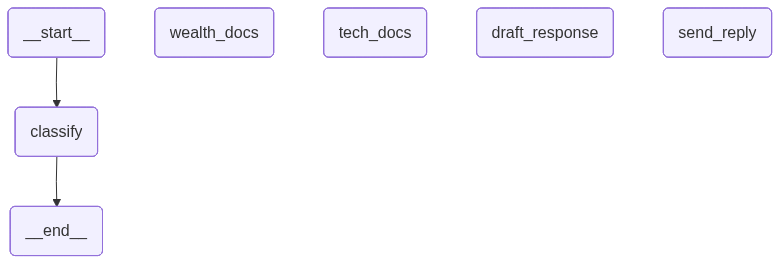

In [64]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [66]:
initial_state = {
    "messages": [HumanMessage(content="Hii! What is wealth? and how can we be wealthy?")]
}
graph.invoke(initial_state)

{'search_query': 'definition of wealth and ways to achieve wealth', 'topic': 'Wealth'}
[AIMessage(content='Hello and welcome. I\'m glad you reached out with your question about wealth and how to achieve it. Wealth is a concept that has been discussed by many successful individuals in the industry, and I\'d like to share some insights with you based on their perspectives.\n\nAccording to renowned experts, wealth is not just about accumulating money, but rather about creating assets that can generate income while you\'re not actively working. As one successful entrepreneur put it, "Wealth is the thing you want. Wealth is assets that earn while you sleep; it’s the factory of robots cranking out things." This means that wealth is about creating systems, businesses, or investments that can produce value without requiring your direct involvement.\n\nTo illustrate this point, consider the example of a computer program that runs at night, serving customers and generating revenue without any ma

{'classify': {'search_query': 'definition of wealth and ways to achieve wealth',
  'topic': 'Wealth'},
 'docSearch': ['Wealth is the thing you want. Wealth is assets that earn while you sleep; it’s the factory of robots cranking out things.',
  'Wealth is the computer program running at night that’s serving other customers. Wealth is money in the bank that is reinvested into other assets and businesses.',
  'A house can be a form of wealth, because you can rent it out; although that’s a less productive use of land than running a commercial enterprise.My definition of wealth is oriented toward businesses and assets that can earn while you sleep.'],
 'messages': [AIMessage(content='Hello and welcome. I\'m glad you reached out with your question about wealth and how to achieve it. Wealth is a concept that has been discussed by many successful individuals in the industry, and I\'d like to share some insights with you based on their perspectives.\n\nAccording to renowned experts, wealth is 